# Customer Churn Prediction
**Dataset:** Telco Customer Churn (Kaggle)
**Goal:** Predict customers likely to leave a service or subscription
**Models:** Logistic Regression | Decision Tree | Neural Network


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries loaded successfully!")


All libraries loaded successfully!


## 2. Load & Explore Data

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print("First 5 rows:")
df.head()


Shape: (7043, 21)
First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [7]:
print("Statistical Summary:")
df.describe()


Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis (EDA)

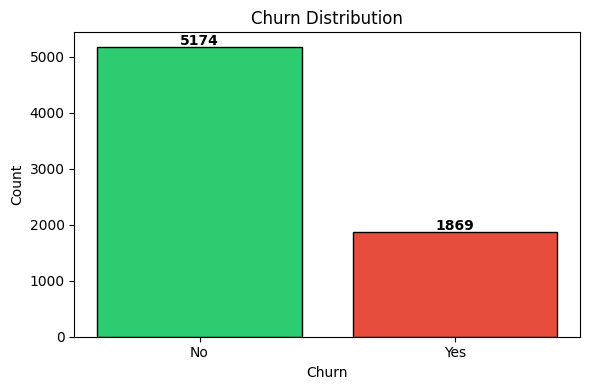

No Churn: 5174 | Churn: 1869


In [8]:
# Churn Distribution
churn_counts = df["Churn"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"], edgecolor="black")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"No Churn: {churn_counts[0]} | Churn: {churn_counts[1]}")


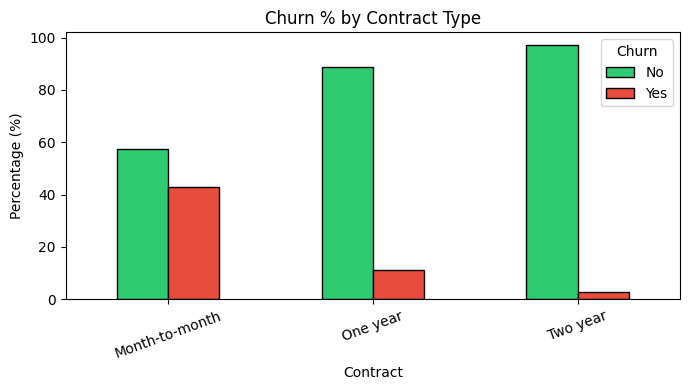

In [9]:
# Churn by Contract Type
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
ct.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="black", figsize=(7, 4), rot=20)
plt.title("Churn % by Contract Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()


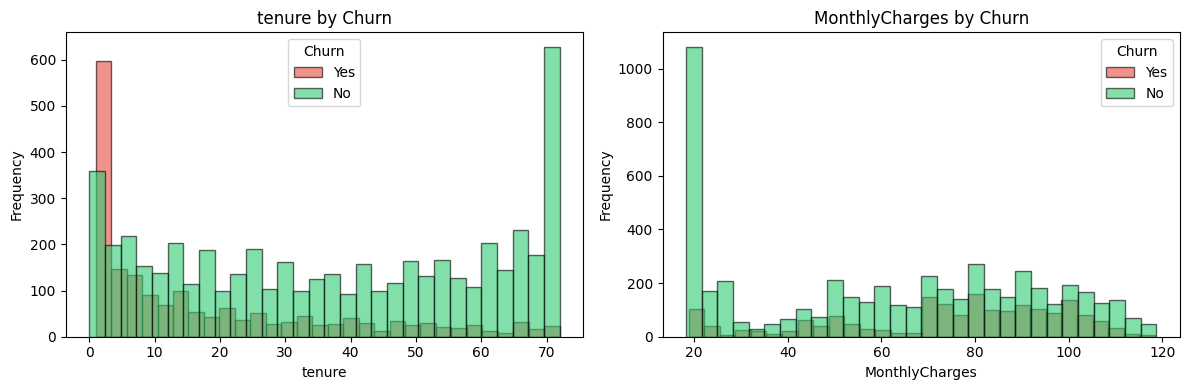

In [10]:
# Tenure vs Monthly Charges by Churn
df_plot = df.copy()
df_plot["TotalCharges"] = pd.to_numeric(df_plot["TotalCharges"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    for churn_val, color in [("Yes", "#e74c3c"), ("No", "#2ecc71")]:
        data = df_plot[df_plot["Churn"] == churn_val][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=churn_val, edgecolor="black")
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(title="Churn")
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [11]:
# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print("Missing values after fix:", df.isnull().sum().sum())


Missing values after fix: 0


In [12]:
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

print("Encoding complete.")
df.head()


Encoding complete.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 5. Train-Test Split & SMOTE

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print("Before SMOTE:")
print(y_train.value_counts())


Train: 5634 samples | Test: 1409 samples
Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64


In [14]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


## 6. Model Training & Evaluation

### 6.1 Logistic Regression

In [15]:
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))


=== Logistic Regression ===
Accuracy: 0.7417
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



### 6.2 Decision Tree

In [16]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sm, y_train_sm)

y_pred_dt = dt.predict(X_test)
print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["No Churn", "Churn"]))


=== Decision Tree ===
Accuracy: 0.7757
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



### 6.3 Neural Network

In [18]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [19]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train_sm, y_train_sm,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6759 - loss: 0.6095 - val_accuracy: 0.7061 - val_loss: 0.6506
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7499 - loss: 0.4980 - val_accuracy: 0.7351 - val_loss: 0.5864
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7538 - loss: 0.4868 - val_accuracy: 0.7866 - val_loss: 0.5368
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7703 - loss: 0.4711 - val_accuracy: 0.7778 - val_loss: 0.5305
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7710 - loss: 0.4618 - val_accuracy: 0.7939 - val_loss: 0.4964
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7839 - loss: 0.4589 - val_accuracy: 0.7987 - val_loss: 0.4935
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7797 - loss: 0.4560 - val_accuracy: 0.8011 - val_loss: 0.4931
Epoch 8/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7841 - loss: 0.4517 - val_accuracy: 0

In [20]:
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print("=== Neural Network ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(classification_report(y_test, y_pred_nn, target_names=["No Churn", "Churn"]))


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
=== Neural Network ===
Accuracy: 0.7544
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.73      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.77      1409

